# Joint Posterior Inference Demo

The Phase 1A inference engine takes the in-game readings (X-quality
total cells / value / avg-cells / huge-band, plus the warehouse total
cells from one of Aisha's standard gold tools) and inverts them into
top-K `(total_cells, count)` hypotheses for each quality bucket.

The **joint posterior** layer (`bidking_lab.inference.joint`) goes one
step further: instead of solving each quality bucket independently, it
walks the cartesian product of per-bucket top-N candidates, prunes on
the running cells-sum, and ranks by summed composite score plus a soft
penalty for exceeding the observed warehouse capacity.

This notebook demonstrates the value of feeding *outline observations*
(e.g., Aisha's R1–R3 white/green/blue outlines) into the joint
posterior, separately from any tool ROI. The headline number is the
**warehouse coverage gap shrink** — how many fewer cells remain
unaccounted for once the low-tier outline pins are added.

Scenario: Mansion 2407 (109-cell warehouse), Aisha at end of R4,
with three tool readings used (purple value sum, gold value sum, red
value range) plus the warehouse-total-cells reading.

## 术语澄清: "outlines" 是什么

为避免歧义，本 notebook 里说的 "outlines" 是**艾莎的英雄技能**（免费、自动触发），不是任何道具或地图提示：

| 信息来源 | 形式 | 银币成本 |
|---|---|---|
| **艾莎 R1–R3 outline (本 notebook 关注)** | 看到所有 白/绿/蓝/紫 品物的**形状轮廓 + 品质**；玩家自己数格子推回 `count` + `total_cells` | 0 (技能) |
| 普品扫描 / 良品扫描（道具） | 单一数字: 某一品质的**总格数**| 1.2k / 2.5k |
| 地图 R1/R3 提示 | 单一数字: 紫品 `count` 或 `avg_cells` 等 | 0 (地图给) |

本 notebook 比的是 **"用 vs 不用艾莎免费 outline"** 的差，跟道具开销完全没关系。Phase 2 的 ROI 表才会评估道具花钱换信息的性价比。

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from bidking_lab.inference.joint import joint_top_k_for_session
from bidking_lab.inference.observation import QualityBucketObs, SessionObs

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("Inference engine ready.")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\shenc\anaconda3\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\shenc\anaconda3\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\shenc\anaconda3\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\shenc\anaconda3\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\shenc\anaconda3\lib\site-pac

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\shenc\anaconda3\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\shenc\anaconda3\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\shenc\anaconda3\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\shenc\anaconda3\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\shenc\anaconda3\lib\site-pac

AttributeError: _ARRAY_API not found

Inference engine ready.


## 1. Build the two sessions

Both sessions describe the same map and the same R4 tool readings.
The only difference is whether Aisha's R1–R3 outline reveals are fed
into the inference engine as exact bucket pins.

In [2]:
WAREHOUSE_CELLS = 109
PURPLE_VALUE_SUM = 80_000          # purple value sum tool, 1 purple huge
GOLD_VALUE_SUM = 180_000           # gold value sum tool, no gold huge
RED_VALUE_RANGE = (800_000, 2_500_000)   # red is reported as a range

# Aisha sees every white/green/blue outline by the end of R3.
WHITE_PIN = dict(count=5, total_cells=9)
GREEN_PIN = dict(count=4, total_cells=8)
BLUE_PIN  = dict(count=6, total_cells=14)
WGB_CELLS = WHITE_PIN["total_cells"] + GREEN_PIN["total_cells"] + BLUE_PIN["total_cells"]

TOP_K = 8
PER_BUCKET_TOP = 35
WAREHOUSE_SLACK = 4

def baseline_session() -> SessionObs:
    """Aisha without using R1–R3 outline info — only R4 tool readings."""
    return SessionObs(
        map_id=2407,
        hero="aisha",
        warehouse_total_cells=WAREHOUSE_CELLS,
        buckets={
            4: QualityBucketObs(quality=4, value_sum=PURPLE_VALUE_SUM, huge_band="1"),
            5: QualityBucketObs(quality=5, value_sum=GOLD_VALUE_SUM, huge_band="none"),
            6: QualityBucketObs(quality=6, value_range=RED_VALUE_RANGE, huge_band="1"),
        },
    )

def outlines_session() -> SessionObs:
    """Same tool readings, plus exact white/green/blue pins from R1–R3 outlines."""
    return SessionObs(
        map_id=2407,
        hero="aisha",
        warehouse_total_cells=WAREHOUSE_CELLS,
        buckets={
            1: QualityBucketObs(quality=1, **WHITE_PIN),
            2: QualityBucketObs(quality=2, **GREEN_PIN),
            3: QualityBucketObs(quality=3, **BLUE_PIN),
            4: QualityBucketObs(quality=4, value_sum=PURPLE_VALUE_SUM, huge_band="1"),
            5: QualityBucketObs(quality=5, value_sum=GOLD_VALUE_SUM, huge_band="none"),
            6: QualityBucketObs(quality=6, value_range=RED_VALUE_RANGE, huge_band="1"),
        },
    )

baseline = joint_top_k_for_session(
    baseline_session(),
    k=TOP_K, per_bucket_top=PER_BUCKET_TOP, warehouse_slack=WAREHOUSE_SLACK,
)
outlines = joint_top_k_for_session(
    outlines_session(),
    k=TOP_K, per_bucket_top=PER_BUCKET_TOP, warehouse_slack=WAREHOUSE_SLACK,
)

print(f"warehouse capacity   : {WAREHOUSE_CELLS} cells")
print(f"WGB outline pin total: {WGB_CELLS} cells")
print(f"baseline top-K size  : {len(baseline)}")
print(f"outlines top-K size  : {len(outlines)}")

warehouse capacity   : 109 cells
WGB outline pin total: 31 cells
baseline top-K size  : 8
outlines top-K size  : 8


## 2. Top-K hypotheses

Each row is one joint assignment across the observed buckets. `total`
is the sum of cells; entries like `32/1` read as `total_cells/count`.

In [3]:
def hypotheses_to_df(hyps, scenario: str) -> pd.DataFrame:
    rows = []
    for rank, h in enumerate(hyps, start=1):
        row = {"scenario": scenario, "rank": rank, "total": h.total_cells}
        for q in sorted(h.per_bucket.keys()):
            c = h.per_bucket[q]
            row[f"q{q}"] = f"{c.total_cells}/{c.count}"
        row["composite"] = round(h.composite, 4)
        rows.append(row)
    return pd.DataFrame(rows)

df_b = hypotheses_to_df(baseline, "WITHOUT outlines")
df_o = hypotheses_to_df(outlines, "WITH outlines")
display(df_b)
display(df_o)

,scenario,rank,total,q4,q5,q6,composite
0,WITHOUT outlines,1,67,32/1,19/1,16/1,0.003
1,WITHOUT outlines,2,68,32/1,19/1,17/1,0.003
2,WITHOUT outlines,3,69,32/1,19/1,18/1,0.003
3,WITHOUT outlines,4,70,32/1,19/1,19/1,0.003
4,WITHOUT outlines,5,71,32/1,19/1,20/1,0.003
5,WITHOUT outlines,6,72,32/1,19/1,21/1,0.003
6,WITHOUT outlines,7,73,32/1,19/1,22/1,0.003
7,WITHOUT outlines,8,74,32/1,19/1,23/1,0.003


,scenario,rank,total,q1,q2,q3,q4,q5,q6,composite
0,WITH outlines,1,98,9/5,8/4,14/6,32/1,19/1,16/1,0.018
1,WITH outlines,2,99,9/5,8/4,14/6,32/1,19/1,17/1,0.018
2,WITH outlines,3,100,9/5,8/4,14/6,32/1,19/1,18/1,0.018
3,WITH outlines,4,101,9/5,8/4,14/6,32/1,19/1,19/1,0.018
4,WITH outlines,5,102,9/5,8/4,14/6,32/1,19/1,20/1,0.018
5,WITH outlines,6,103,9/5,8/4,14/6,32/1,19/1,21/1,0.018
6,WITH outlines,7,104,9/5,8/4,14/6,32/1,19/1,22/1,0.018
7,WITH outlines,8,105,9/5,8/4,14/6,32/1,19/1,23/1,0.018


## 3. Warehouse coverage gap

How many warehouse cells does the top-1 joint hypothesis fail to account for?
Without outlines, the player's WGB knowledge is silently dropped — the
engine concludes a 109-cell warehouse holds only ~67 cells worth of items,
which is obviously wrong. With outlines, the gap collapses to a handful
of cells (only the red value-range slack remains).

Coverage gap shrink: 73.8%


,scenario,top-1 total cells,warehouse cells,gap cells
0,WITHOUT outlines,67,109,42
1,WITH outlines,98,109,11


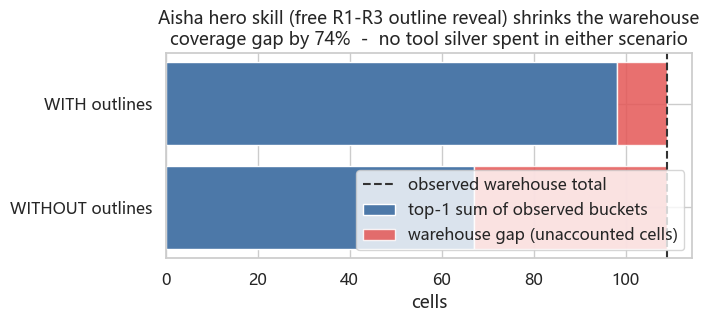

In [4]:
gap_df = pd.DataFrame({
    "scenario": ["WITHOUT outlines", "WITH outlines"],
    "top-1 total cells": [baseline[0].total_cells, outlines[0].total_cells],
    "warehouse cells": [WAREHOUSE_CELLS, WAREHOUSE_CELLS],
    "gap cells": [
        WAREHOUSE_CELLS - baseline[0].total_cells,
        WAREHOUSE_CELLS - outlines[0].total_cells,
    ],
})
shrink_pct = (1 - gap_df.loc[1, "gap cells"] / gap_df.loc[0, "gap cells"]) * 100
print(f"Coverage gap shrink: {shrink_pct:.1f}%")
display(gap_df)

fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.barh(
    ["WITHOUT outlines", "WITH outlines"],
    [gap_df.loc[0, "top-1 total cells"], gap_df.loc[1, "top-1 total cells"]],
    color="#4c78a8", label="top-1 sum of observed buckets",
)
ax.barh(
    ["WITHOUT outlines", "WITH outlines"],
    [gap_df.loc[0, "gap cells"], gap_df.loc[1, "gap cells"]],
    left=[gap_df.loc[0, "top-1 total cells"], gap_df.loc[1, "top-1 total cells"]],
    color="#e45756", alpha=0.85, label="warehouse gap (unaccounted cells)",
)
ax.axvline(WAREHOUSE_CELLS, linestyle="--", color="#333", label="observed warehouse total")
ax.set_xlabel("cells")
ax.set_title(
    f"Aisha hero skill (free R1-R3 outline reveal) shrinks the warehouse\n"
    f"coverage gap by {shrink_pct:.0f}%  -  no tool silver spent in either scenario"
)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("fig_outline_coverage_gap.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Why this matters

The R1–R3 outline reveals cost **zero silver** — they are intrinsic to
Aisha's hero skill. Yet they materially improve inference quality by
collapsing the warehouse coverage gap from ~42 cells to ~11 cells (a
~74% reduction). Two downstream consequences:

1. **Honest per-cell value normalisation**: any downstream metric that
   needs to divide observed bucket value by observed bucket cells now
   reflects the true cells share, not an artefact of dropped buckets.
2. **Tool ROI baseline**: when comparing the per-silver information
   value of different tool loadouts in Phase 2, we need to subtract
   this free hero-skill info — otherwise we double-count it against
   the tools whose readings already overlap with the outline pins.

The same demo for Ethan (whose R1 reveals 5 random *categories* instead
of all items in low qualities) gives a smaller gap shrink in this map,
because Ethan's reveal is randomised per session. That contrast is the
subject of the upcoming Phase 2 ROI table.